In [2]:
import pandas as pd
df=pd.read_csv(r"C:\Users\PAVAN K P\Downloads\cleaned_disease_dataset.csv")
df

,fever,headache,nausea,vomiting,fatigue,disease
0,1,0,1,0,1,Paralysis (brain hemorrhage)
1,0,0,1,0,0,Paralysis (brain hemorrhage)
2,0,0,1,0,1,Paralysis (brain hemorrhage)
3,0,0,1,1,1,Paralysis (brain hemorrhage)
4,1,0,1,0,1,Paralysis (brain hemorrhage)
...,...,...,...,...,...,...
1995,1,1,0,0,1,Alcoholic hepatitis
1996,1,0,0,0,1,Alcoholic hepatitis
1997,1,0,0,1,0,Alcoholic hepatitis
1998,0,0,0,0,1,Alcoholic hepatitis


In [3]:
df.columns

Index(['fever', 'headache', 'nausea', 'vomiting', 'fatigue', 'disease'], dtype='object')

In [4]:
x=df.iloc[:,:-1]
x

,fever,headache,nausea,vomiting,fatigue
0,1,0,1,0,1
1,0,0,1,0,0
2,0,0,1,0,1
3,0,0,1,1,1
4,1,0,1,0,1
...,...,...,...,...,...
1995,1,1,0,0,1
1996,1,0,0,0,1
1997,1,0,0,1,0
1998,0,0,0,0,1


In [5]:
df.describe()

,fever,headache,nausea,vomiting,fatigue
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.328000,0.413000,0.378500,0.526000,0.365500
std,0.469602,0.492496,0.485134,0.499448,0.481691
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,1.000000,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000


In [6]:
df.corr(numeric_only=True)

,fever,headache,nausea,vomiting,fatigue
fever,1.000000,-0.025800,-0.007237,-0.019315,-0.090159
headache,-0.025800,1.000000,-0.036936,-0.035542,-0.044078
nausea,-0.007237,-0.036936,1.000000,-0.031345,0.056336
vomiting,-0.019315,-0.035542,-0.031345,1.000000,0.127868
fatigue,-0.090159,-0.044078,0.056336,0.127868,1.000000


In [7]:
s=pd.get_dummies(x['fever'],drop_first=False,dtype=int)
s

,0,1
0,0,1
1,1,0
2,1,0
3,1,0
4,0,1
...,...,...
1995,0,1
1996,0,1
1997,0,1
1998,1,0


In [8]:
x=x.drop('fever',axis=1) 
x


,headache,nausea,vomiting,fatigue
0,0,1,0,1
1,0,1,0,0
2,0,1,0,1
3,0,1,1,1
4,0,1,0,1
...,...,...,...,...
1995,1,0,0,1
1996,0,0,0,1
1997,0,0,1,0
1998,0,0,0,1


In [9]:
y=(df['disease'])
y

0       Paralysis (brain hemorrhage)
1       Paralysis (brain hemorrhage)
2       Paralysis (brain hemorrhage)
3       Paralysis (brain hemorrhage)
4       Paralysis (brain hemorrhage)
                    ...             
1995             Alcoholic hepatitis
1996             Alcoholic hepatitis
1997             Alcoholic hepatitis
1998             Alcoholic hepatitis
1999             Alcoholic hepatitis
Name: disease, Length: 2000, dtype: object

In [10]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [11]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((1600, 4), (400, 4), (1600,), (400,))

In [12]:
df.shape

(2000, 6)

In [13]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()
model

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [14]:
model.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [15]:
y_pred=model.predict(x_test)
y_pred

array(['Hypertension', 'Gastroenteritis', 'Bronchial Asthma', 'Malaria',
       'Cervical spondylosis', 'Hepatitis B', 'Bronchial Asthma',
       'Paralysis (brain hemorrhage)', 'Urinary tract infection',
       'Paralysis (brain hemorrhage)', 'Paralysis (brain hemorrhage)',
       'Hypoglycemia', 'Hypoglycemia', 'Malaria', 'Bronchial Asthma',
       'Malaria', 'Paralysis (brain hemorrhage)', 'Hepatitis B',
       'Hypertension', 'Hepatitis B', 'Hypertension', 'Gastroenteritis',
       'Hepatitis A', 'Hypertension', 'Dimorphic hemorrhoids(piles)',
       'Dimorphic hemorrhoids(piles)', 'Typhoid', 'Malaria',
       'Dimorphic hemorrhoids(piles)', 'Typhoid', 'Cervical spondylosis',
       'Malaria', 'Hepatitis A', 'Gastroenteritis', 'Hepatitis A',
       'Bronchial Asthma', 'Paralysis (brain hemorrhage)', 'Hypoglycemia',
       'Cervical spondylosis', 'Dimorphic hemorrhoids(piles)',
       'Hypertension', 'Paralysis (brain hemorrhage)', 'Malaria',
       'Dimorphic hemorrhoids(piles)', '

In [16]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, y_pred))

0.195


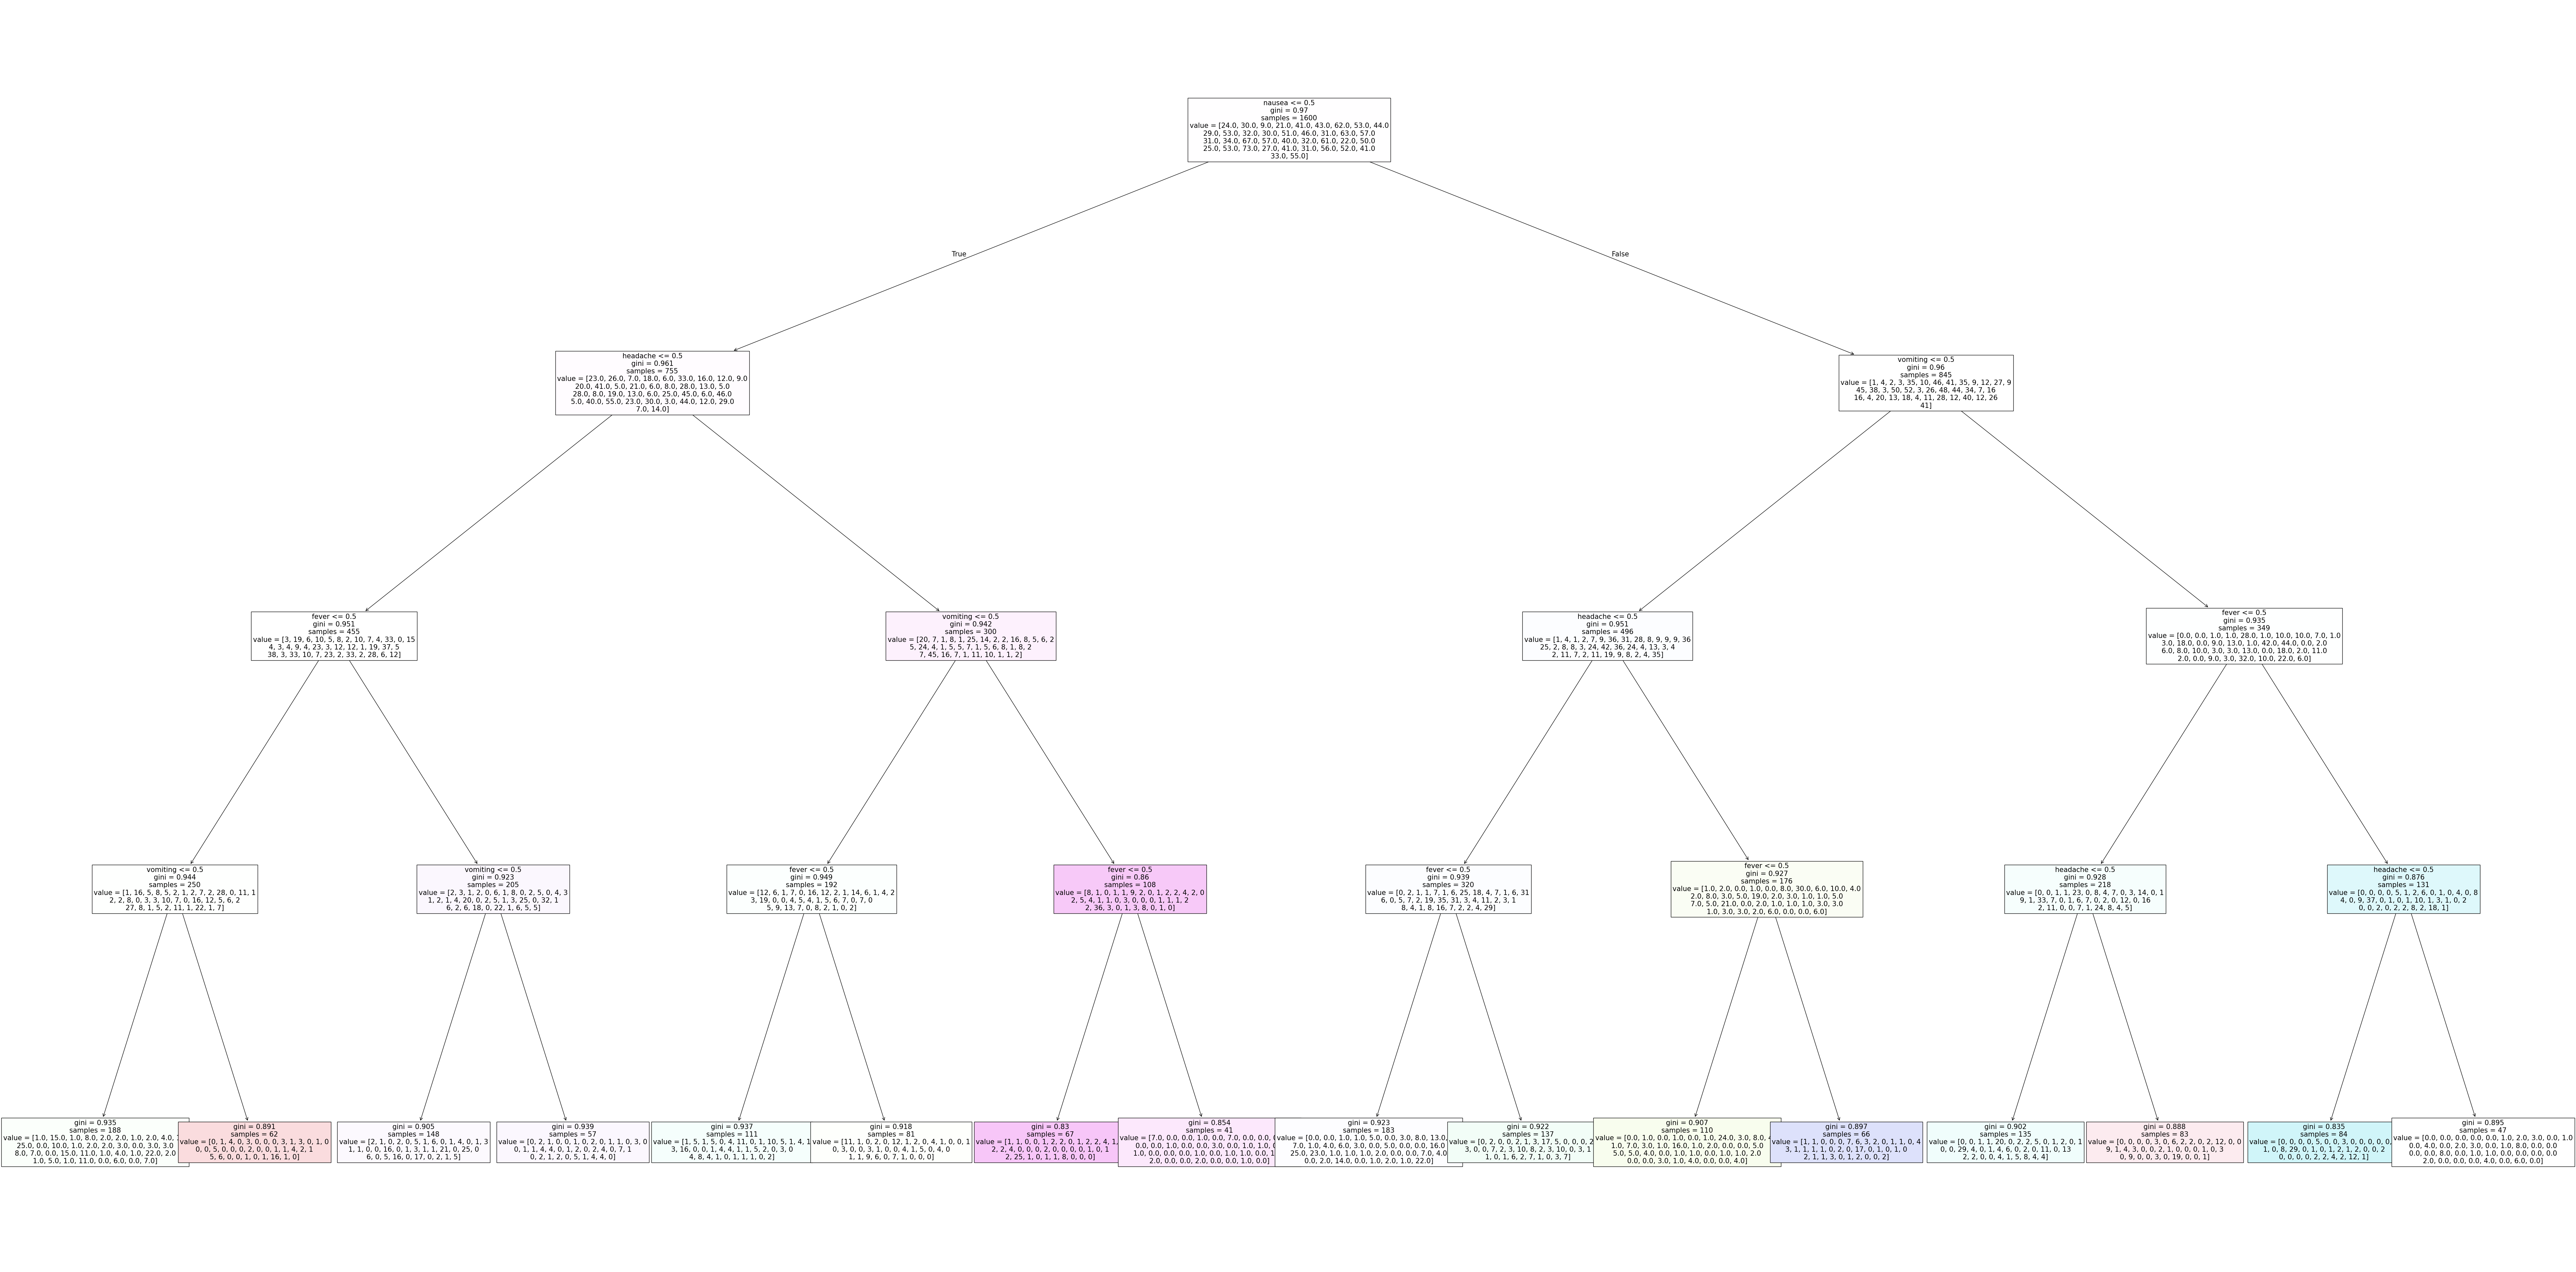

In [36]:
plt.figure(figsize=(100, 50)) 
tree.plot_tree(
    model,
    feature_names=['fever','headache','nausea','vomiting','fatigue'],
    filled=True,
    fontsize=15
)
plt.show()